In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("../data/smart_city_public_safety_raw.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 10200
Columns: 15


,Incident_ID,Incident_Type,Area,Time_of_Day,Day_of_Week,Weather,Crowd_Level,CCTV_Available,Police_Response_Time,Ambulance_Response_Time,Fire_Response_Time,Number_of_People,Severity_Score,Previous_Incidents,Emergency_Level
0,1,Theft,Central,Morning,Friday,Rainy,Low,Yes,10.0,12,12,13,2,8,Medium
1,2,Medical,South,Night,Tuesday,Rainy,High,No,19.0,24,5,112,2,7,Medium
2,3,Accident,South,Afternoon,Sunday,Rainy,Low,Yes,25.0,18,25,389,1,5,Medium
3,4,Theft,West,Morning,Thursday,Sunny,High,No,14.0,24,20,50,7,11,High
4,5,Theft,South,Evening,Monday,Sunny,Low,No,21.0,11,8,454,10,11,High


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Incident_ID              10200 non-null  int64  
 1   Incident_Type            10200 non-null  str    
 2   Area                     10200 non-null  str    
 3   Time_of_Day              10200 non-null  str    
 4   Day_of_Week              10200 non-null  str    
 5   Weather                  9995 non-null   str    
 6   Crowd_Level              9995 non-null   str    
 7   CCTV_Available           10200 non-null  str    
 8   Police_Response_Time     9995 non-null   float64
 9   Ambulance_Response_Time  10200 non-null  int64  
 10  Fire_Response_Time       10200 non-null  int64  
 11  Number_of_People         10200 non-null  int64  
 12  Severity_Score           10200 non-null  int64  
 13  Previous_Incidents       10200 non-null  int64  
 14  Emergency_Level          10200 no

In [28]:
df.describe()

,Incident_ID,Police_Response_Time,Ambulance_Response_Time,Fire_Response_Time,Number_of_People,Severity_Score,Previous_Incidents
count,10200.000000,9995.000000,10200.000000,10200.000000,10200.000000,10200.000000,10200.000000
mean,4994.257549,13.850725,17.497647,19.452843,250.742059,5.467353,10.195686
std,2887.925792,6.651502,7.451210,9.271394,144.099722,2.884874,6.044540
min,1.000000,3.000000,5.000000,4.000000,1.000000,1.000000,0.000000
25%,2486.750000,8.000000,11.000000,11.000000,126.000000,3.000000,5.000000
50%,4995.500000,14.000000,18.000000,19.000000,252.000000,5.000000,10.000000
75%,7496.250000,20.000000,24.000000,28.000000,377.000000,8.000000,15.000000
max,10000.000000,25.000000,30.000000,35.000000,500.000000,10.000000,20.000000


In [29]:
df.isnull().sum()

Incident_ID                  0
Incident_Type                0
Area                         0
Time_of_Day                  0
Day_of_Week                  0
Weather                    205
Crowd_Level                205
CCTV_Available               0
Police_Response_Time       205
Ambulance_Response_Time      0
Fire_Response_Time           0
Number_of_People             0
Severity_Score               0
Previous_Incidents           0
Emergency_Level              0
dtype: int64

In [30]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 200


In [31]:
df["Weather"] = df["Weather"].fillna(df["Weather"].mode()[0])

df["Crowd_Level"] = df["Crowd_Level"].fillna(df["Crowd_Level"].mode()[0])

df["Police_Response_Time"] = df["Police_Response_Time"].fillna(
    df["Police_Response_Time"].median()
)

In [32]:
print(df.isnull().sum())

Incident_ID                0
Incident_Type              0
Area                       0
Time_of_Day                0
Day_of_Week                0
Weather                    0
Crowd_Level                0
CCTV_Available             0
Police_Response_Time       0
Ambulance_Response_Time    0
Fire_Response_Time         0
Number_of_People           0
Severity_Score             0
Previous_Incidents         0
Emergency_Level            0
dtype: int64


In [33]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (10200, 15)
After: (10000, 15)


In [34]:
numeric_columns = df.select_dtypes(include=np.number).columns

print(numeric_columns)

Index(['Incident_ID', 'Police_Response_Time', 'Ambulance_Response_Time',
       'Fire_Response_Time', 'Number_of_People', 'Severity_Score',
       'Previous_Incidents'],
      dtype='str')


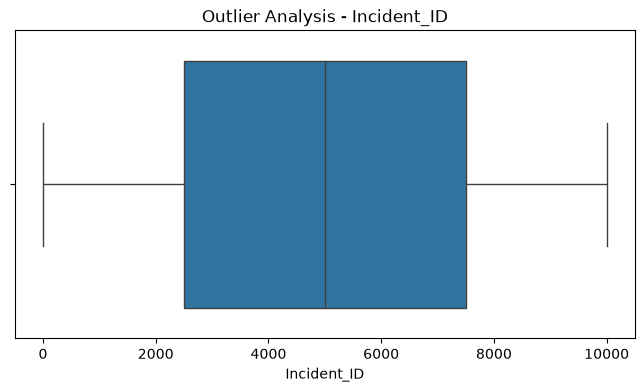

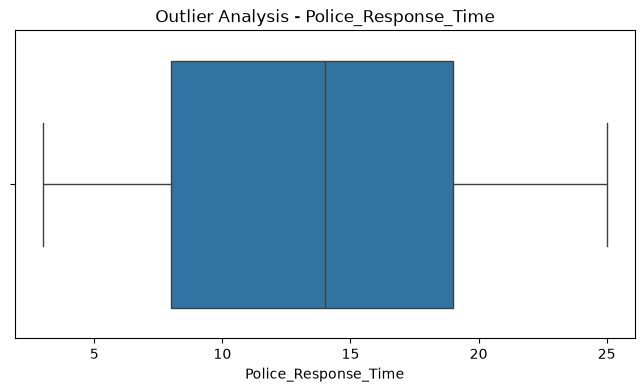

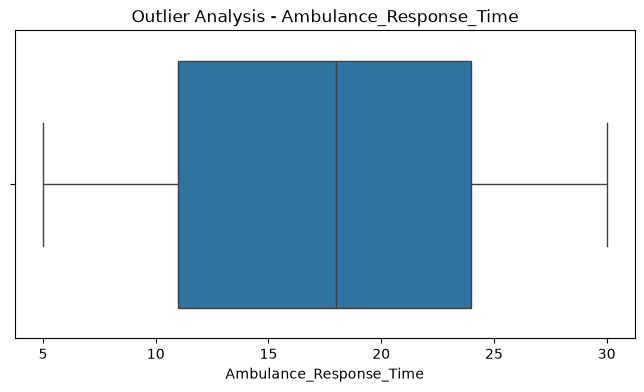

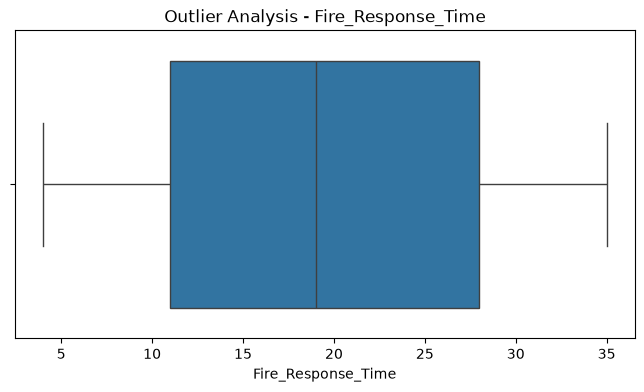

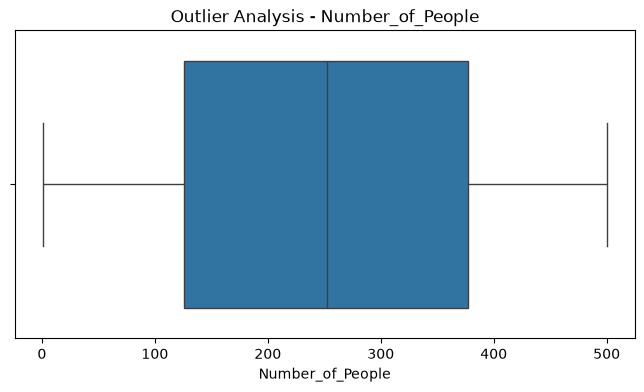

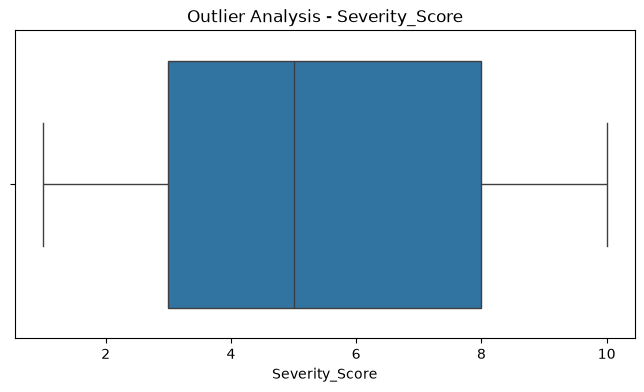

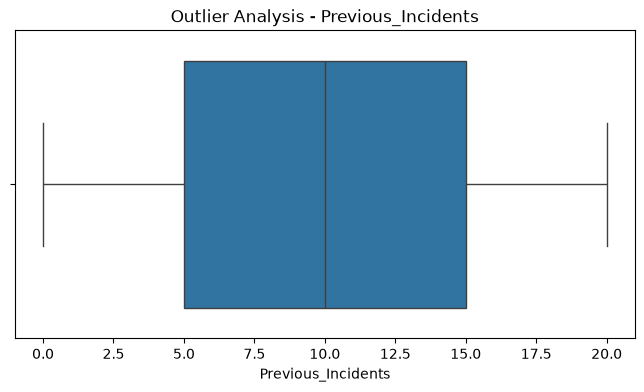

In [35]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Analysis - {col}")
    plt.show()

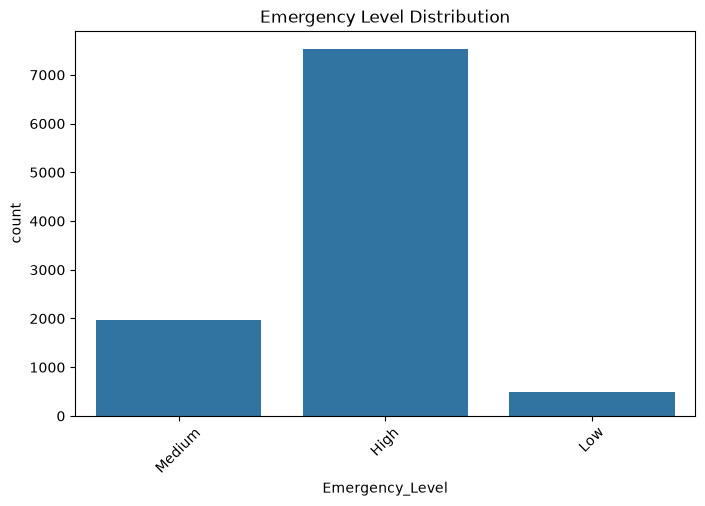

In [36]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Emergency_Level")
plt.title("Emergency Level Distribution")
plt.xticks(rotation=45)
plt.show()

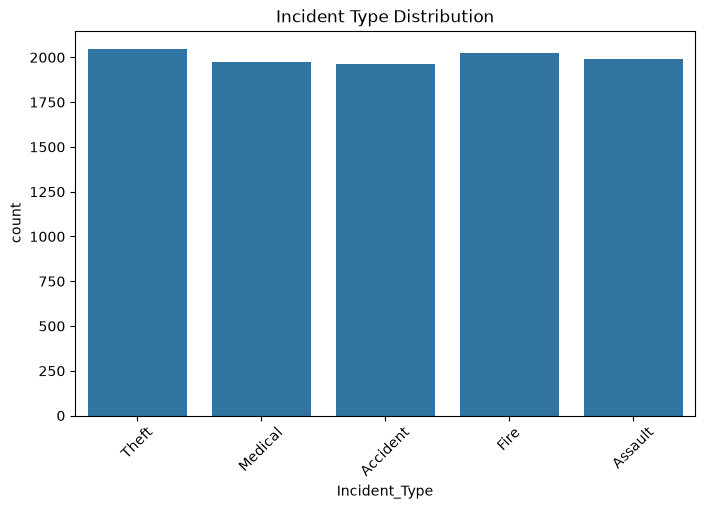

In [37]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Incident_Type")
plt.title("Incident Type Distribution")
plt.xticks(rotation=45)
plt.show()

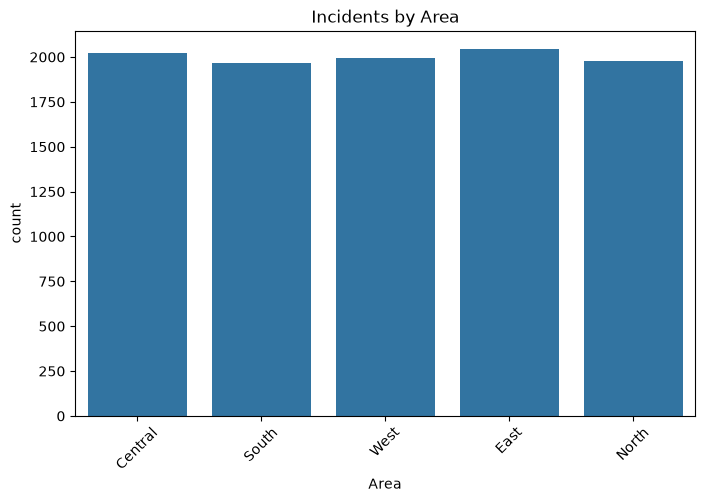

In [38]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Area")
plt.title("Incidents by Area")
plt.xticks(rotation=45)
plt.show()

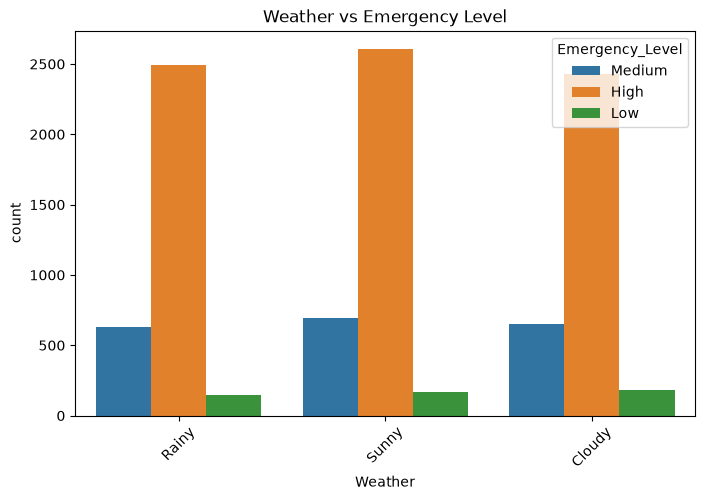

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Weather", hue="Emergency_Level")
plt.title("Weather vs Emergency Level")
plt.xticks(rotation=45)
plt.show()

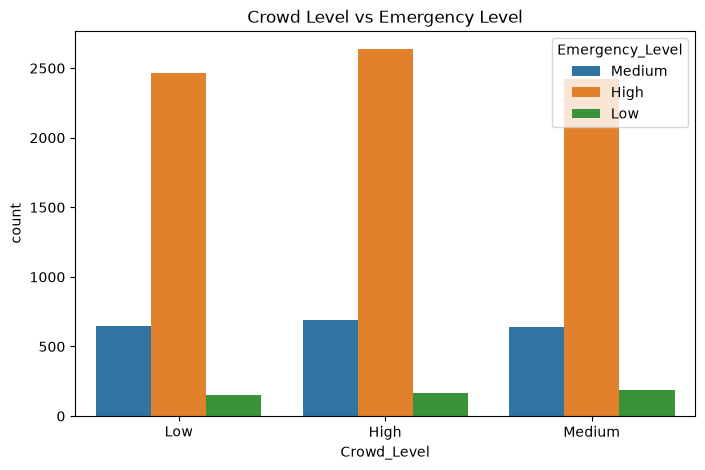

In [40]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Crowd_Level", hue="Emergency_Level")
plt.title("Crowd Level vs Emergency Level")
plt.show()

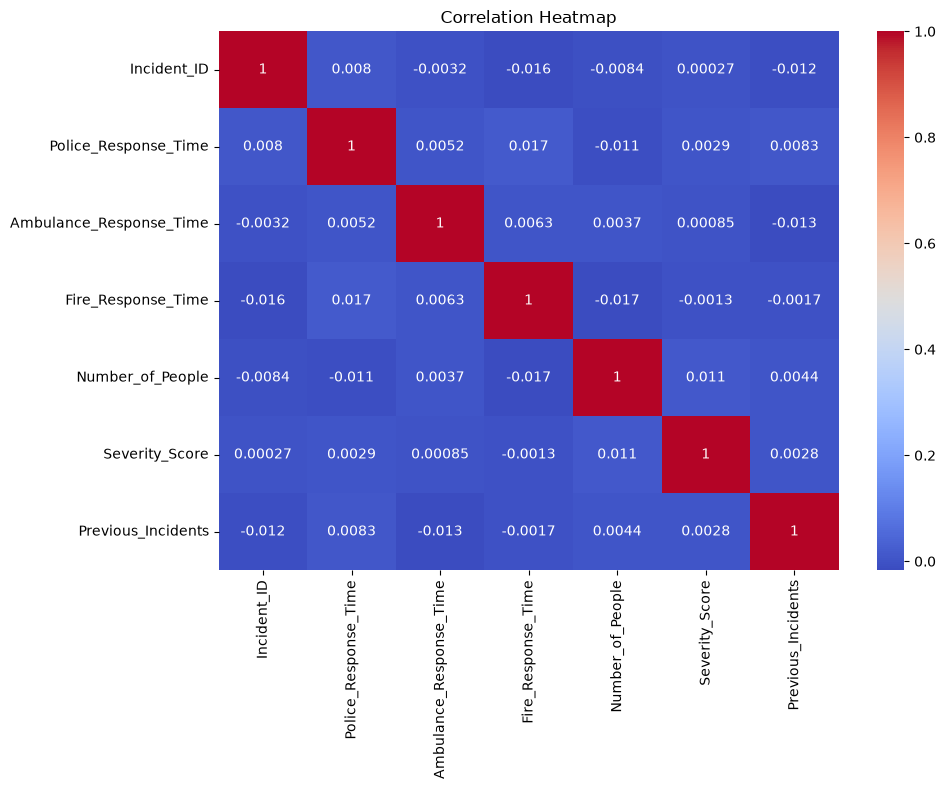

In [41]:
plt.figure(figsize=(10, 7))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [42]:
df.to_csv("../data/smart_city_thiranex_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [43]:
plt.savefig("../visualizations/emergency_level_distribution.png",
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [44]:
plt.savefig("../visualizations/incident_type_distribution.png",
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [45]:
plt.savefig("../visualizations/incidents_by_area.png",
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [46]:
plt.savefig("../visualizations/weather_vs_emergency.png",
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [47]:
plt.savefig("../visualizations/crowd_vs_emergency.png",
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [48]:
plt.savefig("../visualizations/correlation_heatmap.png",
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>